In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("../plots.mplstyle")


In [11]:
def load_csv(csv_file, two_channel=False):
    data = np.genfromtxt(csv_file, delimiter=",", skip_header=1)
    t = np.asarray(data[:, 0], dtype=np.float32)
    ch1 = np.asarray(data[:, 1], dtype=np.float32)
    if two_channel: 
        ch2 = np.asarray(data[:, 2], dtype=np.float32)
        return t, ch1, ch2
    return t, ch1

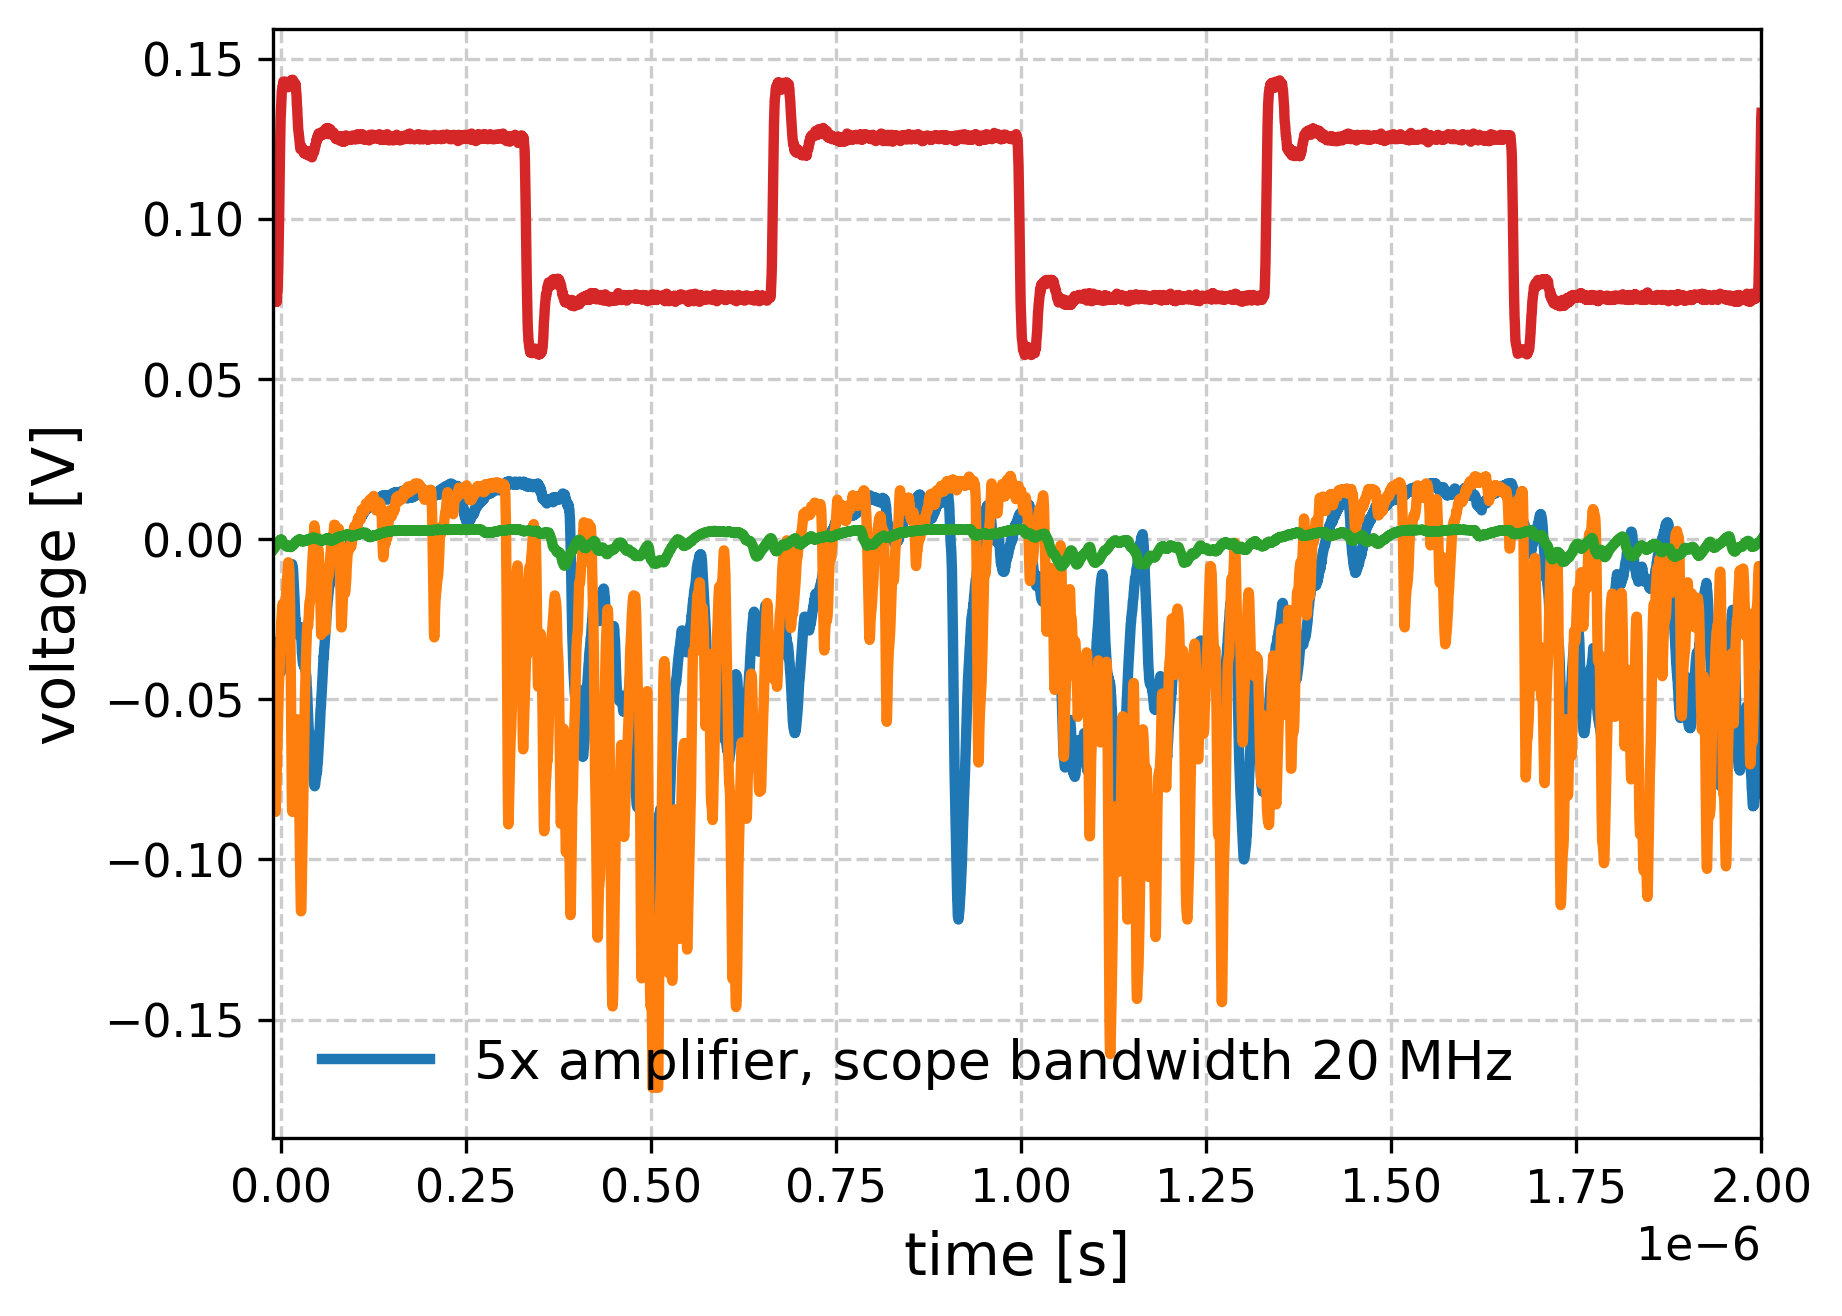

In [50]:
t, ch1_amp_20_mhz = load_csv("./amp-20-mhz.csv")
t, ch1_amp_full = load_csv("./amp-full-bandwidth.csv")
t, ch1_no_amp_20_mhz = load_csv("./no-amp-20mhz.csv")
t, _, signal = load_csv("./diff-setup-20-mhz-amp.csv", True)




fig, ax = plt.subplots(dpi=300)
ax.plot(t, ch1_amp_20_mhz, label="5x amplifier, scope bandwidth 20 MHz")
ax.plot(t, ch1_amp_full)
ax.plot(t, ch1_no_amp_20_mhz)
ax.set_xlabel("time [s]")
ax.set_ylabel("voltage [V]")
ax.plot(t, signal / 100 + 0.1)
ax.set_xlim([-1e-8, 2e-6])

# smoothed = np.convolve(ch1_amp_20_mhz, np.ones(70)/70, mode='same')
# ax.plot(t, smoothed, label="smoothed")

plt.legend()


In [47]:

def average_over_periods(t, voltage, period, n_bins=None):
    t = np.asarray(t)
    voltage = np.asarray(voltage)

    if n_bins is None:
        n_bins = max(100, int(len(t) / ((t[-1] - t[0]) / period)))

    phase = np.mod(t, period)

    edges = np.linspace(0, period, n_bins + 1)
    inds = np.digitize(phase, edges) - 1
    inds = np.clip(inds, 0, n_bins - 1)

    counts = np.bincount(inds, minlength=n_bins)
    sums = np.bincount(inds, weights=voltage, minlength=n_bins)

    avg_voltage = sums / np.maximum(counts, 1)
    t_period = 0.5 * (edges[:-1] + edges[1:])

    return t_period, avg_voltage

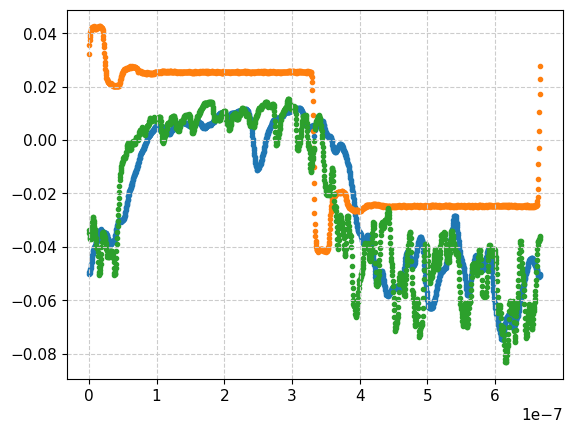

In [55]:
t_one_period, avg = average_over_periods(t, ch1_amp_20_mhz, 1/1.5e6)
t_one_period_2, avg_2 = average_over_periods(t, signal, 1/1.5e6)
t_one_period_3, avg_3 = average_over_periods(t, ch1_amp_full, 1/1.5e6)



fig, ax = plt.subplots()
ax.scatter(t_one_period, avg)
ax.scatter(t_one_period_2, avg_2 / 100)
ax.scatter(t_one_period_3, avg_3)
